In [11]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
)
import shap
import warnings

warnings.filterwarnings("ignore")

# Set visual style for all plots
sns.set_style("whitegrid")
plt.rcParams["figure.figsize"] = (10, 6)

In [12]:
# Step 2: Load Dataset

# Since this dataset uses semicolons as separators we'll
# filter on that instead of commas
df = pd.read_csv("cardio_dataset.csv", sep=";")

# Preview the first 5 rows
df.head()

# Check column types and whether any values are missing
df.info()

# Summary statistics
df.describe()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 70000 entries, 0 to 69999
Data columns (total 13 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   id           70000 non-null  int64  
 1   age          70000 non-null  int64  
 2   gender       70000 non-null  int64  
 3   height       70000 non-null  int64  
 4   weight       70000 non-null  float64
 5   ap_hi        70000 non-null  int64  
 6   ap_lo        70000 non-null  int64  
 7   cholesterol  70000 non-null  int64  
 8   gluc         70000 non-null  int64  
 9   smoke        70000 non-null  int64  
 10  alco         70000 non-null  int64  
 11  active       70000 non-null  int64  
 12  cardio       70000 non-null  int64  
dtypes: float64(1), int64(12)
memory usage: 6.9 MB


,id,age,gender,height,weight,ap_hi,ap_lo,cholesterol,gluc,smoke,alco,active,cardio
count,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000,70000.000000
mean,49972.419900,19468.865814,1.349571,164.359229,74.205690,128.817286,96.630414,1.366871,1.226457,0.088129,0.053771,0.803729,0.499700
std,28851.302323,2467.251667,0.476838,8.210126,14.395757,154.011419,188.472530,0.680250,0.572270,0.283484,0.225568,0.397179,0.500003
min,0.000000,10798.000000,1.000000,55.000000,10.000000,-150.000000,-70.000000,1.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,25006.750000,17664.000000,1.000000,159.000000,65.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
50%,50001.500000,19703.000000,1.000000,165.000000,72.000000,120.000000,80.000000,1.000000,1.000000,0.000000,0.000000,1.000000,0.000000
75%,74889.250000,21327.000000,2.000000,170.000000,82.000000,140.000000,90.000000,2.000000,1.000000,0.000000,0.000000,1.000000,1.000000
max,99999.000000,23713.000000,2.000000,250.000000,200.000000,16020.000000,11000.000000,3.000000,3.000000,1.000000,1.000000,1.000000,1.000000


In [13]:
# Step 3: Data Cleaning

# Convert age from days to years
df["age_years"] = (df["age"] / 365).round(1)

print(f"Rows before cleaning: {len(df)}")

# Remove extreme blood pressure values
# According to Google, Systolic should be between 70-250
# diastolic between 40-200
df = df[(df["ap_hi"] >= 70) & (df["ap_hi"] <= 250)]
df = df[(df["ap_lo"] >= 40) & (df["ap_lo"] <= 200)]
df = df[df["ap_hi"] > df["ap_lo"]]

print(f"Rows after cleaning:  {len(df)}")

Rows before cleaning: 70000
Rows after cleaning:  68671


In [14]:
# Step 4: BMI Feature Add

# Calculate BMI from height and weight
df["bmi"] = df["weight"] / ((df["height"] / 100) ** 2)

# Create BMI categories using WHO standards
def categorize_bmi(bmi):
    if bmi < 18.5:
        return "Underweight"
    elif bmi < 25:
        return "Normal"
    elif bmi < 30:
        return "Overweight"
    else:
        return "Obese"

df["bmi_category"] = df["bmi"].apply(categorize_bmi)

print("BMI Category Distribution:")
print(df["bmi_category"].value_counts())

BMI Category Distribution:
bmi_category
Normal         25425
Overweight     24623
Obese          17980
Underweight      643
Name: count, dtype: int64


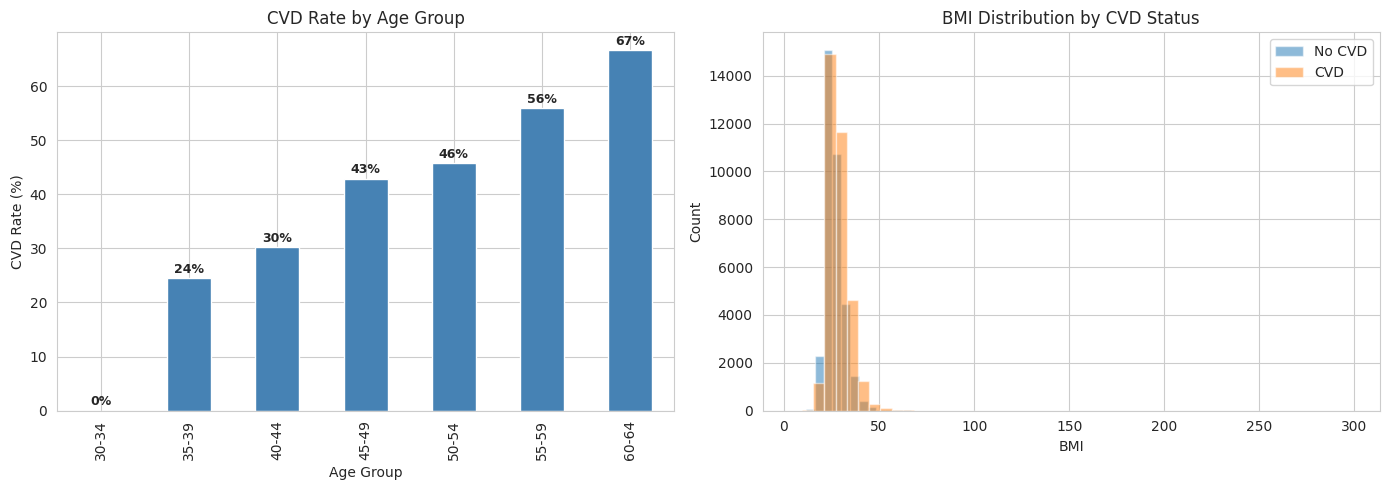

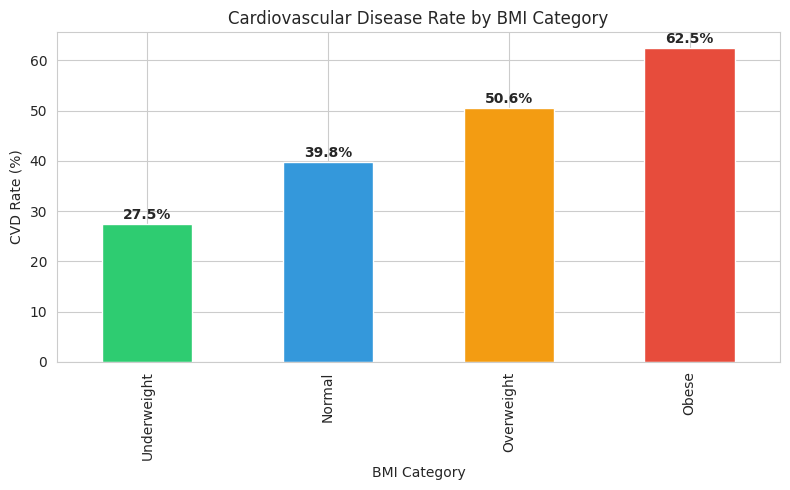

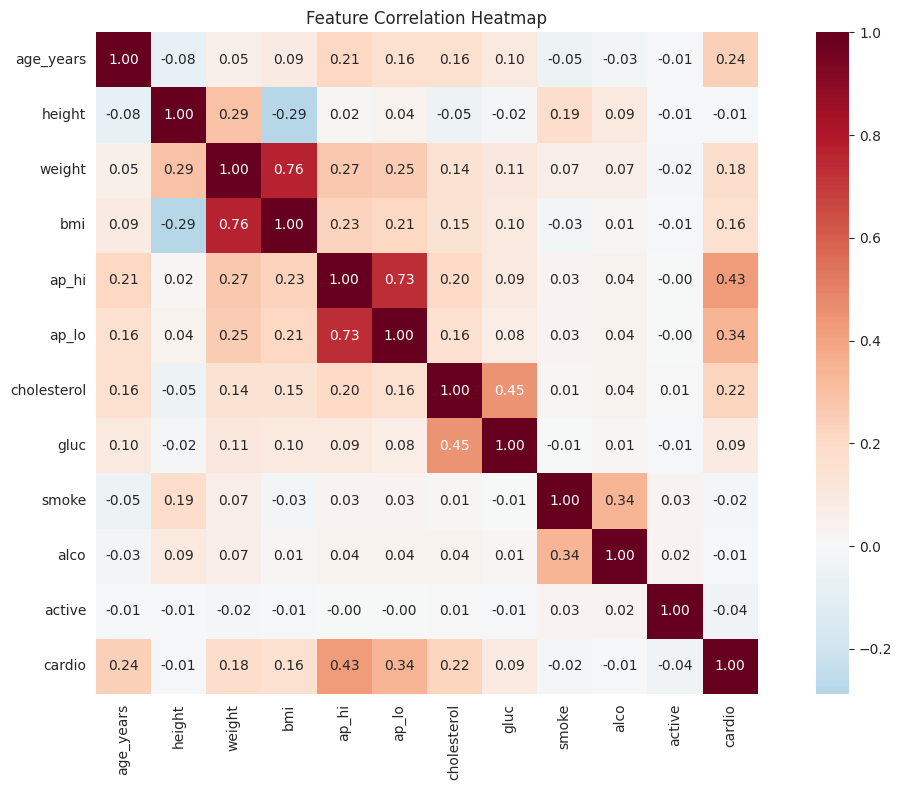

In [15]:
# Step 5: Some Data Analysis
# Some of the plotting code was written with the assistance of Claude Opus 4.6

# Plot 1: CVD rate by age group and BMI distribution by CVD status
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Left: Age and CVD
age_bins = [30, 35, 40, 45, 50, 55, 60, 65]
age_labels = ["30-34", "35-39", "40-44", "45-49", "50-54", "55-59", "60-64"]
df["age_group"] = pd.cut(df["age_years"], bins=age_bins, labels=age_labels, right=False)
cvd_by_age = df.groupby("age_group", observed=True)["cardio"].mean() * 100

cvd_by_age.plot(kind="bar", ax=axes[0], color="steelblue")
axes[0].set_title("CVD Rate by Age Group")
axes[0].set_xlabel("Age Group")
axes[0].set_ylabel("CVD Rate (%)")
for i, v in enumerate(cvd_by_age):
    axes[0].text(i, v + 1, f"{v:.0f}%", ha="center", fontweight="bold", fontsize=9)

# Right: BMI and CVD
for label, group in df.groupby("cardio"):
    axes[1].hist(group["bmi"], bins=50, alpha=0.5,
                 label=f"{'CVD' if label == 1 else 'No CVD'}")
axes[1].set_title("BMI Distribution by CVD Status")
axes[1].set_xlabel("BMI")
axes[1].set_ylabel("Count")
axes[1].legend()

plt.tight_layout()
plt.show()

# Plot 2: CVD rate & BMI category: does obesity correlate with CVD?
fig, ax = plt.subplots(figsize=(8, 5))
bmi_order = ["Underweight", "Normal", "Overweight", "Obese"]
cvd_by_bmi = df.groupby("bmi_category")["cardio"].mean().reindex(bmi_order) * 100

cvd_by_bmi.plot(kind="bar", ax=ax, color=["#2ecc71", "#3498db", "#f39c12", "#e74c3c"])
ax.set_title("Cardiovascular Disease Rate by BMI Category")
ax.set_xlabel("BMI Category")
ax.set_ylabel("CVD Rate (%)")

for i, v in enumerate(cvd_by_bmi):
    ax.text(i, v + 1, f"{v:.1f}%", ha="center", fontweight="bold")

plt.tight_layout()
plt.show()

# Plot 3: Correlation heatmap: which features correlate with CVD?
fig, ax = plt.subplots(figsize=(12, 8))
numeric_cols = ["age_years", "height", "weight", "bmi", "ap_hi", "ap_lo",
                "cholesterol", "gluc", "smoke", "alco", "active", "cardio"]
correlation = df[numeric_cols].corr()
sns.heatmap(correlation, annot=True, fmt=".2f", cmap="RdBu_r",
            center=0, ax=ax, square=True)
ax.set_title("Feature Correlation Heatmap")
plt.tight_layout()
plt.show()

In [16]:
# Step 6: Prep Data for ML

# Define the feature columns and target
feature_cols = ["age_years", "gender", "height", "weight", "bmi",
                "ap_hi", "ap_lo", "cholesterol", "gluc",
                "smoke", "alco", "active"]

X = df[feature_cols]
y = df["cardio"]

# Split 80/20
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y)


In [17]:
# Step 7: Train ML Model

# Train the Random Forest model
rf_model = RandomForestClassifier(
    n_estimators=200,
    max_depth=10,
    min_samples_split=10,
    random_state=42,
    n_jobs=-1)
rf_model.fit(X_train, y_train)

# Generate predictions and probabilities on the test set
rf_preds = rf_model.predict(X_test)
rf_probs = rf_model.predict_proba(X_test)[:, 1]

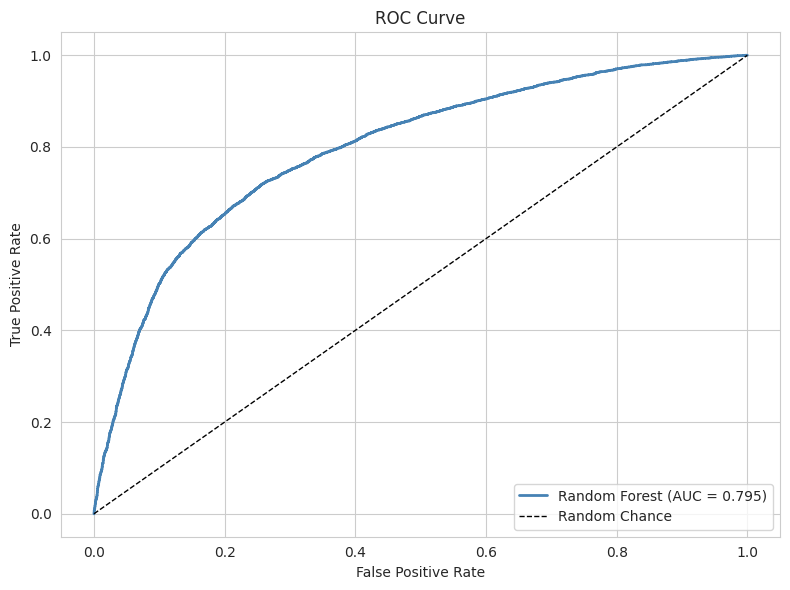

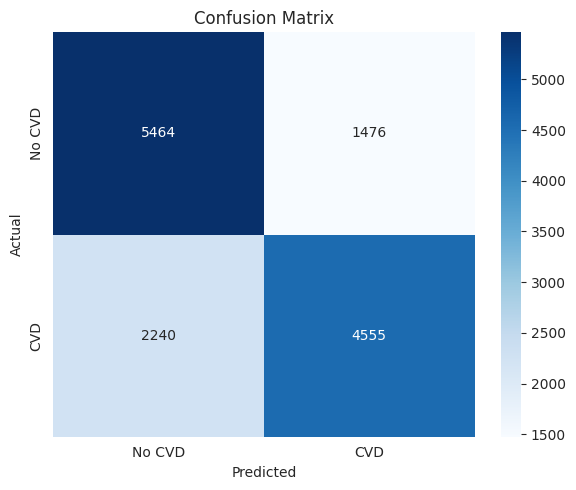

In [18]:
# Step 8: Model Eval

# Print accuracy, AUC, and the full classification
acc = accuracy_score(y_test, rf_preds)
auc = roc_auc_score(y_test, rf_probs)

# ROC Curve
fig, ax = plt.subplots(figsize=(8, 6))

fpr, tpr, _ = roc_curve(y_test, rf_probs)
ax.plot(fpr, tpr, color="steelblue", lw=2, label=f"Random Forest (AUC = {auc:.3f})")
ax.plot([0, 1], [0, 1], "k--", lw=1, label="Random Chance")
ax.set_xlabel("False Positive Rate")
ax.set_ylabel("True Positive Rate")
ax.set_title("ROC Curve")
ax.legend(loc="lower right")
plt.tight_layout()
plt.show()

# Confusion Matrix
fig, ax = plt.subplots(figsize=(6, 5))
cm = confusion_matrix(y_test, rf_preds)
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", ax=ax,
            xticklabels=["No CVD", "CVD"], yticklabels=["No CVD", "CVD"])
ax.set_title("Confusion Matrix")
ax.set_xlabel("Predicted")
ax.set_ylabel("Actual")
plt.tight_layout()
plt.show()

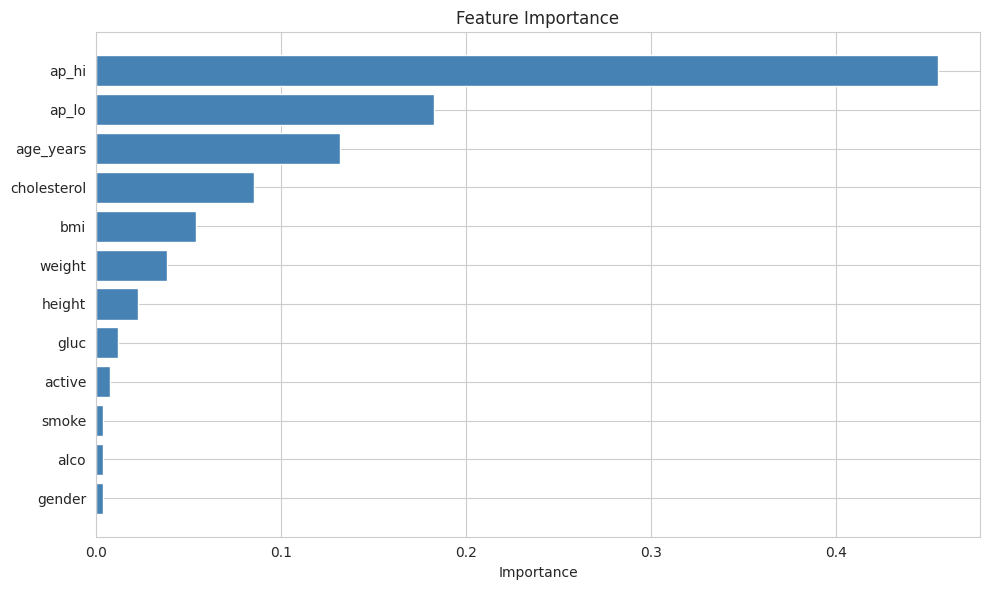

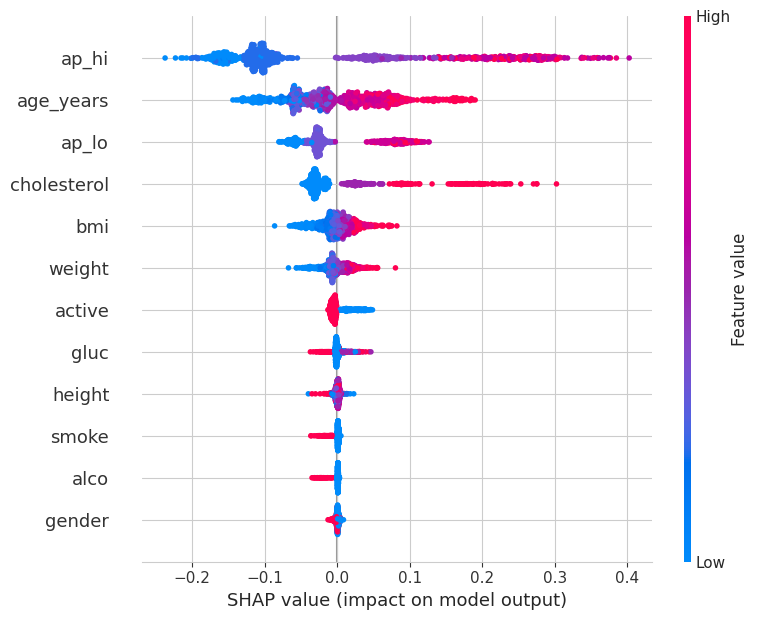

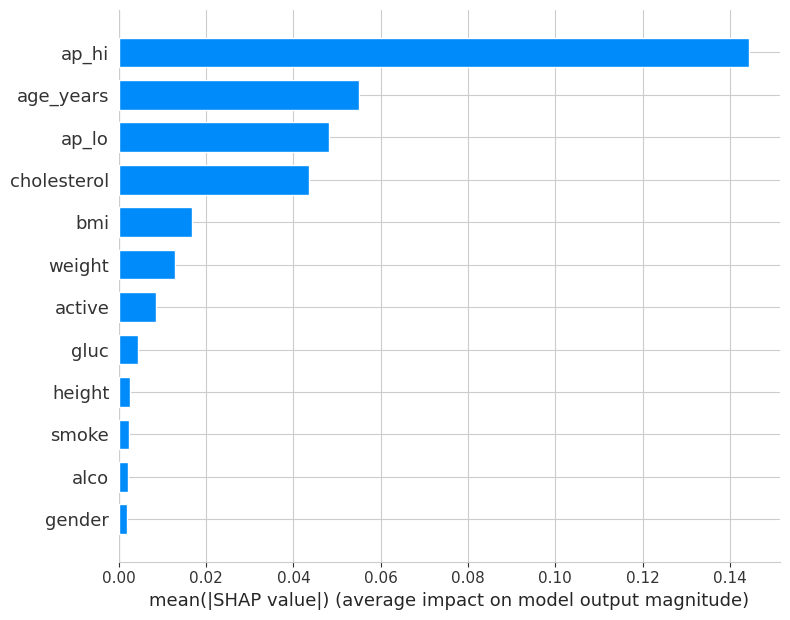

In [19]:
# Step 9: Feature Importance

# Feature importance from Random Forest
fig, ax = plt.subplots(figsize=(10, 6))
importances = rf_model.feature_importances_
sorted_idx = np.argsort(importances)
ax.barh(np.array(feature_cols)[sorted_idx], importances[sorted_idx], color="steelblue")
ax.set_title("Feature Importance")
ax.set_xlabel("Importance")
plt.tight_layout()
plt.show()

# SHAP analysis
X_test_sample = X_test.sample(n=1000, random_state=42)
explainer = shap.TreeExplainer(rf_model)
shap_values = explainer.shap_values(X_test_sample)

# SHAP summary plot
# Red = high feature value
# Blue = low feature value
# Right = pushes prediction toward CVD
# Left = pushes away from CVD
shap.summary_plot(shap_values[:, :, 1], X_test_sample, feature_names=feature_cols)

# SHAP bar plot
shap.summary_plot(shap_values[:, :, 1], X_test_sample, feature_names=feature_cols, plot_type="bar")

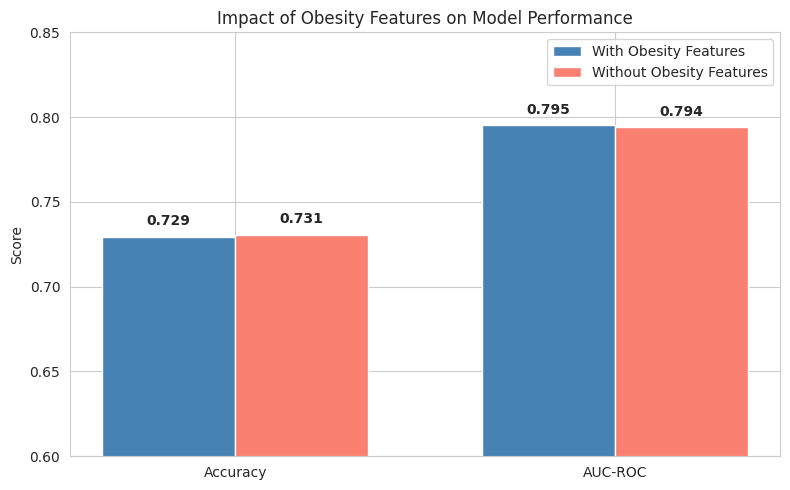

In [20]:
# Step 10: Obesity Focused Analysis

# Define features WITHOUT obesity related variables (no BMI, no weight)
non_obesity_features = ["age_years", "gender", "height",
                        "ap_hi", "ap_lo", "cholesterol", "gluc",
                        "smoke", "alco", "active"]

# Retraining
X_train_no_obesity = X_train[non_obesity_features]
X_test_no_obesity = X_test[non_obesity_features]

rf_no_obesity = RandomForestClassifier(
    n_estimators=200, max_depth=10, min_samples_split=10,
    random_state=42, n_jobs=-1)
rf_no_obesity.fit(X_train_no_obesity, y_train)
no_obesity_preds = rf_no_obesity.predict(X_test_no_obesity)
no_obesity_probs = rf_no_obesity.predict_proba(X_test_no_obesity)[:, 1]

# Compare results
full_acc = accuracy_score(y_test, rf_preds)
full_auc = roc_auc_score(y_test, rf_probs)
reduced_acc = accuracy_score(y_test, no_obesity_preds)
reduced_auc = roc_auc_score(y_test, no_obesity_probs)

# Visualize comparison
fig, ax = plt.subplots(figsize=(8, 5))
x_pos = np.arange(2)
width = 0.35

bars1 = ax.bar(x_pos - width / 2, [full_acc, full_auc], width,
               label="With Obesity Features", color="steelblue")
bars2 = ax.bar(x_pos + width / 2, [reduced_acc, reduced_auc], width,
               label="Without Obesity Features", color="salmon")

ax.set_ylabel("Score")
ax.set_title("Impact of Obesity Features on Model Performance")
ax.set_xticks(x_pos)
ax.set_xticklabels(["Accuracy", "AUC-ROC"])
ax.legend()
ax.set_ylim(0.6, 0.85)

for bars in [bars1, bars2]:
    for bar in bars:
        height = bar.get_height()
        ax.text(bar.get_x() + bar.get_width() / 2., height + 0.005,
                f"{height:.3f}", ha="center", va="bottom", fontweight="bold")

plt.tight_layout()
plt.show()